In [ ]:
#https://colab.research.google.com/drive/1zIeziuWmZEPq-tPaG_NoigaU-sAnxWGr?usp=sharing
from keras.models import Sequential
from keras.layers import Dense
import numpy as np
from keras.datasets import mnist


(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train_038= x_train[np.logical_or.reduce((y_train==0,y_train==3,y_train==8)),0:28,0:28]
y_train_038= y_train[np.logical_or.reduce((y_train==0,y_train==3,y_train==8))]

x_test_038= x_test[np.logical_or.reduce((y_test==0,y_test==3,y_test==8)),0:28,0:28]
y_test_038= y_test[np.logical_or.reduce((y_test==0,y_test==3,y_test==8))]

num_train_img= x_train_038.shape[0]

x_valid_038= x_train_038[0:int(.2*num_train_img),:,:]
y_valid_038= y_train_038[0:int(.2*num_train_img)]


In [ ]:
def feat_extract(images):
  width= images.shape[1]
  height= images.shape[2]
  features= np.zeros((images.shape[0],4))

  features_temporary= np.sum(images[:,0:int(width/2),0:int(height/2)],axis=(1,2))
  features[:,0]=(features_temporary)/(width*height/4)

  features_temporary= np.sum(images[:,0:int(width/2),int(height/2):],axis=(1,2))
  features[:,1]=(features_temporary)/(width*height/4)

  features_temporary= np.sum(images[:,int(width/2):,0:int(height/2)],axis=(1,2))
  features[:,2]=(features_temporary)/(width*height/4)

  features_temporary= np.sum(images[:,int(width/2):,int(height/2):],axis=(1,2))
  features[:,3]=(features_temporary)/(width*height/4)

  return features

In [ ]:
from keras.utils import to_categorical

classes=[0,3,8]

y_train_038= np.array([classes.index(x) for x in y_train_038])
y_valid_038= np.array([classes.index(x) for x in y_valid_038])
y_test_038= np.array([classes.index(x) for x in y_test_038])

y_train_038_c= to_categorical(y_train_038,len(classes))
y_valid_038_c=to_categorical(y_valid_038,len(classes))
y_test_038_c= to_categorical(y_test_038,len(classes))


In [ ]:
x_train_features= feat_extract(x_train_038)
x_test_features= feat_extract(x_test_038)
x_valid_features= feat_extract(x_valid_038)
model= Sequential()
model.add(Dense(input_dim= 4, units=16, activation='tanh'))
model.add(Dense(units= 3, activation='softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4882 - loss: 1.0760 - val_accuracy: 0.5172 - val_loss: 1.0070
Epoch 2/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5352 - loss: 0.9876 - val_accuracy: 0.5719 - val_loss: 0.9487
Epoch 3/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5547 - loss: 0.9536 - val_accuracy: 0.5700 - val_loss: 0.9306
Epoch 4/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5528 - loss: 0.9400 - val_accuracy: 0.5808 - val_loss: 0.9224
Epoch 5/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5544 - loss: 0.9317 - val_accuracy: 0.5797 - val_loss: 0.9146
Epoch 6/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5571 - loss: 0.9247 - val_accuracy: 0.5828 - val_loss: 0.9102
Epoch 7/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5610 - loss: 0.9187 - val_accuracy: 0.5864 - val_loss: 0.9046
Epoch 8/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5667 - loss: 0.9127 - 

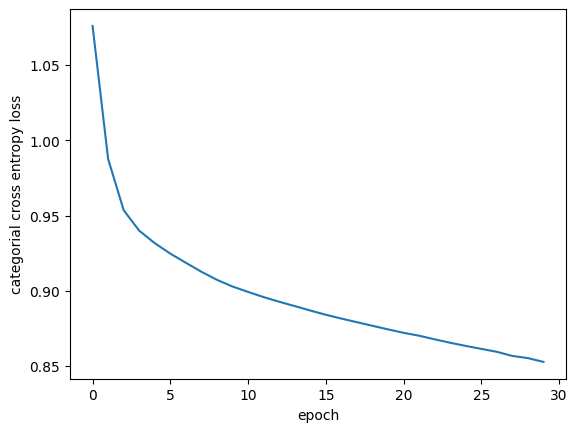

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5865 - loss: 0.8516
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6057 - loss: 0.8374
Training loss: 0.8515648245811462
Validation loss: 0.8374089598655701
Training accuracy: 0.5865400433540344
Validation accuracy: 0.6056967377662659


In [ ]:
from keras.optimizers import SGD
optimizer= SGD(learning_rate=.0001)
model.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#using categorial crossentropy because we have three classes 0 3 and 8 so it is multiclass therefore we use it

history= model.fit(x_train_features,y_train_038_c,batch_size=16,epochs=30,verbose=1,validation_data=(x_valid_features,y_valid_038_c))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('categorial cross entropy loss')
plt.show()

training_loss,training_accuracy = model.evaluate(x_train_features,y_train_038_c)
validation_loss,validation_accuracy= model.evaluate(x_valid_features,y_valid_038_c)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {validation_loss}")
print(f"Training accuracy: {training_accuracy}")
print(f"Validation accuracy: {validation_accuracy}")

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515 (2.01 KB)

 Trainable params: 515 (2.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5145 - loss: 1.0481 - val_accuracy: 0.5526 - val_loss: 0.9860
Epoch 2/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5684 - loss: 0.9642 - val_accuracy: 0.5956 - val_loss: 0.9354
Epoch 3/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5973 - loss: 0.9187 - val_accuracy: 0.6280 - val_loss: 0.8855
Epoch 4/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6120 - loss: 0.8788 - val_accuracy: 0.6392 - val_loss: 0.8511
Epoch 5/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6176 - loss: 0.8570 - val_accuracy: 0.6412 - val_loss: 0.8361
Epoch 6/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6215 - loss: 0.8409 - val_accuracy: 0.6459 - val_loss: 0.8123
Epoch 7/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6256 - loss: 0.8267 - val_accuracy: 0.6579 - val_loss: 0.7979
Epoch 8/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6294 - loss: 0.8153 - 

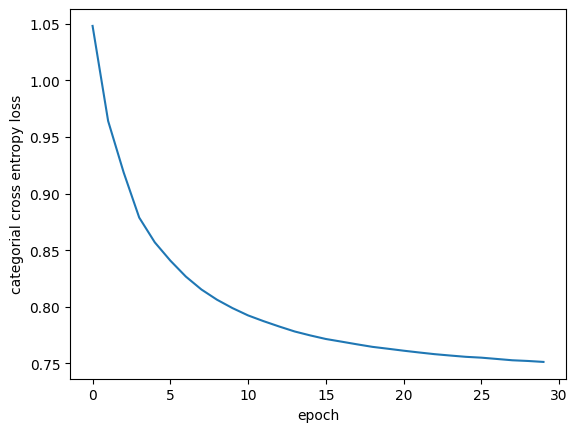

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6582 - loss: 0.7499
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6844 - loss: 0.7204
Training loss: 0.7499201893806458
Validation loss: 0.7203552722930908
Training accuracy: 0.6581960320472717
Validation accuracy: 0.6844456791877747


In [ ]:
model_a= Sequential()
model_a.add(Dense(input_dim= 4, units=64, activation='tanh'))
model_a.add(Dense(units= 3, activation='softmax'))
model_a.summary()
from keras.optimizers import SGD
optimizer= SGD(learning_rate=.0001)
model_a.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#using categorial crossentropy because we have three classes 0 3 and 8 so it is multiclass therefore we use it

history= model_a.fit(x_train_features,y_train_038_c,batch_size=16,epochs=30,verbose=1,validation_data=(x_valid_features,y_valid_038_c))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('categorial cross entropy loss')
plt.show()

training_loss,training_accuracy = model_a.evaluate(x_train_features,y_train_038_c)
validation_loss,validation_accuracy= model_a.evaluate(x_valid_features,y_valid_038_c)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {validation_loss}")
print(f"Training accuracy: {training_accuracy}")
print(f"Validation accuracy: {validation_accuracy}")


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5374 - loss: 0.9815 - val_accuracy: 0.6121 - val_loss: 0.9021
Epoch 2/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6101 - loss: 0.8895 - val_accuracy: 0.6509 - val_loss: 0.8483
Epoch 3/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6336 - loss: 0.8504 - val_accuracy: 0.6641 - val_loss: 0.8156
Epoch 4/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6446 - loss: 0.8269 - val_accuracy: 0.6682 - val_loss: 0.7957
Epoch 5/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6450 - loss: 0.8105 - val_accuracy: 0.6713 - val_loss: 0.7813
Epoch 6/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6503 - loss: 0.7981 - val_accuracy: 0.6694 - val_loss: 0.7683
Epoch 7/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6529 - loss: 0.7885 - val_accuracy: 0.6730 - val_loss: 0.7582
Epoch 8/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6526 - loss: 0.7802 - 

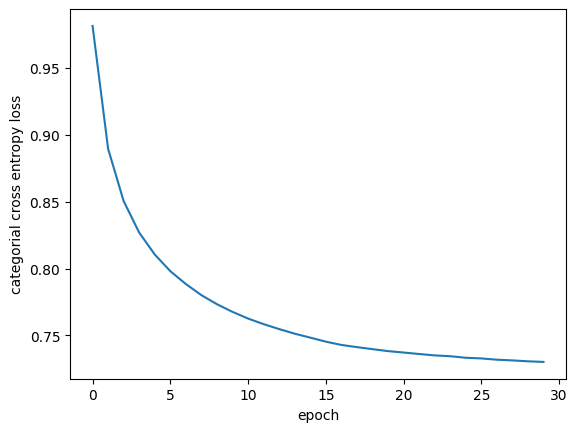

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6673 - loss: 0.7294
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6911 - loss: 0.7003
Training loss: 0.7294393181800842
Validation loss: 0.7002561092376709
Training accuracy: 0.6672996282577515
Validation accuracy: 0.6911477446556091


In [ ]:
model_b= Sequential()
model_b.add(Dense(input_dim= 4, units=128, activation='tanh'))
model_b.add(Dense(units= 3, activation='softmax'))
model_b.summary()
from keras.optimizers import SGD
optimizer= SGD(learning_rate=.0001)
model_b.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#using categorial crossentropy because we have three classes 0 3 and 8 so it is multiclass therefore we use it

history= model_b.fit(x_train_features,y_train_038_c,batch_size=16,epochs=30,verbose=1,validation_data=(x_valid_features,y_valid_038_c))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('categorial cross entropy loss')
plt.show()

training_loss,training_accuracy = model_b.evaluate(x_train_features,y_train_038_c)
validation_loss,validation_accuracy= model_b.evaluate(x_valid_features,y_valid_038_c)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {validation_loss}")
print(f"Training accuracy: {training_accuracy}")
print(f"Validation accuracy: {validation_accuracy}")


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,755 (10.76 KB)

 Trainable params: 2,755 (10.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5319 - loss: 0.9863 - val_accuracy: 0.6238 - val_loss: 0.9167
Epoch 2/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6164 - loss: 0.8981 - val_accuracy: 0.6476 - val_loss: 0.8578
Epoch 3/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6340 - loss: 0.8497 - val_accuracy: 0.6576 - val_loss: 0.8144
Epoch 4/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6393 - loss: 0.8225 - val_accuracy: 0.6613 - val_loss: 0.7983
Epoch 5/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6431 - loss: 0.8080 - val_accuracy: 0.6669 - val_loss: 0.7817
Epoch 6/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6460 - loss: 0.7975 - val_accuracy: 0.6763 - val_loss: 0.7704
Epoch 7/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6484 - loss: 0.7894 - val_accuracy: 0.6800 - val_loss: 0.7628
Epoch 8/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6491 - loss: 0.7830 - 

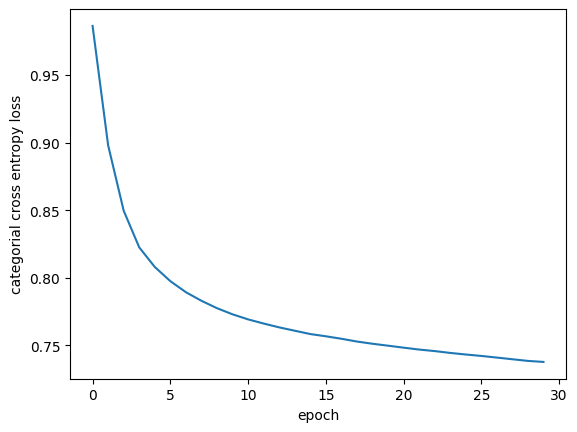

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6682 - loss: 0.7365
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6928 - loss: 0.7059
Training loss: 0.7364540100097656
Validation loss: 0.7059204578399658
Training accuracy: 0.6682490706443787
Validation accuracy: 0.6928232312202454


In [ ]:
model_c= Sequential()
model_c.add(Dense(input_dim= 4, units=128, activation='tanh'))
model_c.add(Dense(units=16, activation='tanh'))
model_c.add(Dense(units= 3, activation='softmax'))
model_c.summary()
from keras.optimizers import SGD
optimizer= SGD(learning_rate=.0001)
model_c.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#using categorial crossentropy because we have three classes 0 3 and 8 so it is multiclass therefore we use it

history= model_c.fit(x_train_features,y_train_038_c,batch_size=16,epochs=30,verbose=1,validation_data=(x_valid_features,y_valid_038_c))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('categorial cross entropy loss')
plt.show()

training_loss,training_accuracy = model_c.evaluate(x_train_features,y_train_038_c)
validation_loss,validation_accuracy= model_c.evaluate(x_valid_features,y_valid_038_c)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {validation_loss}")
print(f"Training accuracy: {training_accuracy}")
print(f"Validation accuracy: {validation_accuracy}")


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,091 (35.51 KB)

 Trainable params: 9,091 (35.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5223 - loss: 1.0230 - val_accuracy: 0.6132 - val_loss: 0.9426
Epoch 2/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6173 - loss: 0.9156 - val_accuracy: 0.6395 - val_loss: 0.8773
Epoch 3/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6342 - loss: 0.8645 - val_accuracy: 0.6590 - val_loss: 0.8307
Epoch 4/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6406 - loss: 0.8318 - val_accuracy: 0.6655 - val_loss: 0.8023
Epoch 5/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6462 - loss: 0.8109 - val_accuracy: 0.6677 - val_loss: 0.7829
Epoch 6/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6492 - loss: 0.7959 - val_accuracy: 0.6724 - val_loss: 0.7667
Epoch 7/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6508 - loss: 0.7848 - val_accuracy: 0.6719 - val_loss: 0.7563
Epoch 8/30
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6540 - loss: 0.7771 - 

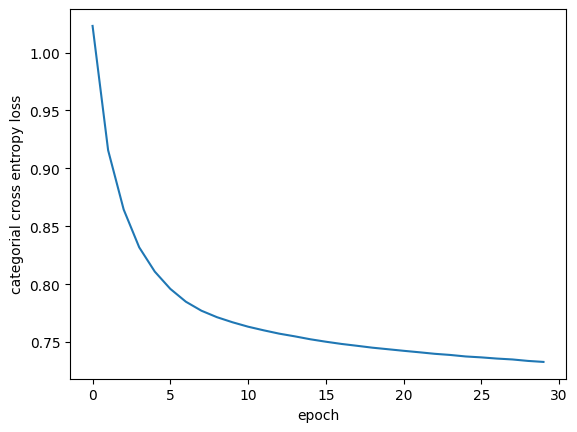

560/560 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6685 - loss: 0.7331
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6909 - loss: 0.7038
Training loss: 0.7331368923187256
Validation loss: 0.7037768363952637
Training accuracy: 0.6684724688529968
Validation accuracy: 0.6908684968948364


In [ ]:
model_d= Sequential()
model_d.add(Dense(input_dim= 4, units=128, activation='tanh'))
model_d.add(Dense(units=64, activation='tanh'))
model_d.add(Dense(units= 3, activation='softmax'))
model_d.summary()
from keras.optimizers import SGD
optimizer= SGD(learning_rate=.0001)
model_d.compile(optimizer= optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
#using categorial crossentropy because we have three classes 0 3 and 8 so it is multiclass therefore we use it

history= model_d.fit(x_train_features,y_train_038_c,batch_size=16,epochs=30,verbose=1,validation_data=(x_valid_features,y_valid_038_c))

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('categorial cross entropy loss')
plt.show()

training_loss,training_accuracy = model_d.evaluate(x_train_features,y_train_038_c)
validation_loss,validation_accuracy= model_d.evaluate(x_valid_features,y_valid_038_c)

print(f"Training loss: {training_loss}")
print(f"Validation loss: {validation_loss}")
print(f"Training accuracy: {training_accuracy}")
print(f"Validation accuracy: {validation_accuracy}")

In [ ]:
'''when we increased the amount of layers and nodes, the training loss and validation loss both decreased
and the graph looks more like what we are used to with it slowly decreasing until it finally starts to
flatten out'''

'when we increased the amount of layers and nodes, the training loss and validation loss both decreased\nand the graph looks more like what we are used to with it slowly decreasing until it finally starts to \nflatten out'

In [ ]:
test_loss,test_accuracy = model.evaluate(x_test_features,y_test_038_c)


print(f"Testing loss: {test_loss}")
print(f"Testing loss: {test_loss}")

test_loss_a,test_accuracy_a = model_a.evaluate(x_test_features,y_test_038_c)


print(f"Testing loss: {test_loss_a}")
print(f"Testing loss: {test_loss_a}")

test_loss_b,test_accuracy_b = model_b.evaluate(x_test_features,y_test_038_c)


print(f"Testing loss: {test_loss_b}")
print(f"Testing loss: {test_loss_b}")

test_loss_c,test_accuracy_c = model_c.evaluate(x_test_features,y_test_038_c)


print(f"Testing loss: {test_loss_c}")
print(f"Testing loss: {test_loss_c}")

test_loss_d,test_accuracy_d = model_d.evaluate(x_test_features,y_test_038_c)


print(f"Testing loss: {test_loss_d}")
print(f"Testing loss: {test_loss_d}")


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5918 - loss: 0.8435
Testing loss: 0.8434532284736633
Testing loss: 0.8434532284736633
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6437 - loss: 0.7561
Testing loss: 0.7561338543891907
Testing loss: 0.7561338543891907
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6579 - loss: 0.7364
Testing loss: 0.7363927960395813
Testing loss: 0.7363927960395813
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6535 - loss: 0.7413
Testing loss: 0.7413280606269836
Testing loss: 0.7413280606269836
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6535 - loss: 0.7372
Testing loss: 0.7372134327888489
Testing loss: 0.7372134327888489


## Project Summary for Resume

**Project Title:** MNIST Digit Classification using Custom Feature Engineering and Keras Dense Networks

**Objective:** Developed and evaluated a neural network model for classifying specific digits (0, 3, 8) from the MNIST dataset.

**Methodology:**
*   **Data Preparation:** Loaded and preprocessed the MNIST dataset, filtering for target digits (0, 3, 8) and splitting into training, validation, and test sets.
*   **Feature Engineering:** Implemented a custom feature extraction function to convert 28x28 pixel images into a 4-dimensional feature vector by averaging pixel intensities across four quadrants of each image.
*   **Model Development:** Constructed multiple Keras Sequential models (Dense Neural Networks) with varying architectures, including different numbers of hidden layers and units (e.g., 16, 64, 128 units) and `tanh` activation functions, culminating in a `softmax` output layer for multi-class classification.
*   **Training & Evaluation:** Trained models using the SGD optimizer with `categorical_crossentropy` loss over 30 epochs. Monitored training and validation loss/accuracy, and visualized loss trends.
*   **Performance Analysis:** Compared models with varying complexities, observing that increasing the number of layers and nodes led to improved training and validation performance (lower loss and higher accuracy) on the filtered MNIST subset.

**Technologies Used:** Python, Keras, NumPy, Matplotlib.

## Resources

### Digit Classification using Custom Feature Engineering and Keras Dense Networks - April, 2026

*   Developed and evaluated a neural network for classifying specific digits (0, 3, 8) from the dataset, leveraging custom feature engineering to reduce 28x28 images to a 4-dimensional feature vector by averaging pixel intensities across quadrants.

*   Designed and trained Keras Dense Neural Networks with varying architectures, demonstrating improved performance (lower loss and higher accuracy) on the filtered digit subset by increasing model complexity, showcasing expertise in data preprocessing, feature extraction, and neural network design using Python, Keras, NumPy, and Matplotlib.